This notebook is used to calculate the relationships between diseases and drugs from a molecular point of view, considering
individual diseases and agglomereted trajectories

In [1]:
import pandas as pd
import pickle as pk
import networkx as nx
import collections
import random as rd
import itertools as it
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

import xml.etree.ElementTree as ET
import time

dB_file = 'input/DrugBank_FullDatabase.xml'
organism = 'Humans'
xtree = ET.parse(dB_file)
xroot = xtree.getroot()


#This method is described here:
#https://github.com/dhimmel/drugbank/blob/gh-pages/parse.ipynb

In [2]:
def fisher_test(lstA, lstB,background):
    import scipy.stats as stats
    """
    Accepts to lists
    M is the population size (previously N)
    n is the number of successes in the population
    N is the sample size (previously n)
    x is still the number of drawn “successes”
    """
    setA= set(lstA)
    setB= set(lstB)
    M= background
    n= len(setA)
    N= len(setB)
    x= len(setA.intersection(setB))

    return str(stats.hypergeom.sf(x-1, M, n, N))

import scipy  
from scipy import stats

#Here we define the adjustment
from statsmodels.sandbox.stats.multicomp import multipletests
def fdr_adjustment(list_of_pvals,alpha):    
    return multipletests(list_of_pvals,alpha=alpha,method='fdr_bh')[1] #the benjamin hochberg method is used

In [3]:
def collapse_list_values(row):
    for key, value in row.items():
        if isinstance(value, list):
            row[key] = '|'.join(value)
    return row


In [4]:
#Let's import the ICD-name dictionary
icd_naming_df = pd.read_csv("output/disease_name.tsv",sep="\t")

In [5]:
#Let's extract the drug information
ns = '{http://www.drugbank.ca}'
inchikey_template = "{ns}calculated-properties/{ns}property[{ns}kind='InChIKey']/{ns}value"
inchi_template = "{ns}calculated-properties/{ns}property[{ns}kind='InChI']/{ns}value"

rows = list()
for i, drug in enumerate(xroot):
    row = collections.OrderedDict()
    assert drug.tag == ns + 'drug'
    row['type'] = drug.get('type')
    row['drugbank_id'] = drug.findtext(ns + "drugbank-id[@primary='true']")
    row['name'] = drug.findtext(ns + "name")
    row['description'] = drug.findtext(ns + "description")
    row['groups'] = [group.text for group in
        drug.findall("{ns}groups/{ns}group".format(ns = ns))]
    row['atc_codes'] = [code.get('code') for code in
        drug.findall("{ns}atc-codes/{ns}atc-code".format(ns = ns))]
    row['categories'] = [x.findtext(ns + 'category') for x in
        drug.findall("{ns}categories/{ns}category".format(ns = ns))]
    row['inchi'] = drug.findtext(inchi_template.format(ns = ns))
    row['inchikey'] = drug.findtext(inchikey_template.format(ns = ns))
    row['indication'] = drug.findtext(ns + "indication")
    row['mechanism-of-action'] = drug.findtext(ns + "mechanism-of-action")

    
    
    # Add drug aliases
    aliases = {
        elem.text for elem in 
        drug.findall("{ns}international-brands/{ns}international-brand".format(ns = ns)) +
        drug.findall("{ns}synonyms/{ns}synonym[@language='English']".format(ns = ns)) +
        drug.findall("{ns}international-brands/{ns}international-brand".format(ns = ns)) +
        drug.findall("{ns}products/{ns}product/{ns}name".format(ns = ns))

    }
    aliases.add(row['name'])
    row['aliases'] = sorted(aliases)

    rows.append(row)

In [6]:
columns = ['drugbank_id', 'name', 'type', 'indication','mechanism-of-action','groups', 'atc_codes', 'categories', 'inchikey', 'inchi', 'description']
drugbank_df = pd.DataFrame.from_dict(rows)[columns]
drugbank_df.head()


,drugbank_id,name,type,indication,mechanism-of-action,groups,atc_codes,categories,inchikey,inchi,description
0,DB00001,Lepirudin,biotech,For the treatment of heparin-induced thrombocy...,Lepirudin forms a stable non-covalent complex ...,[approved],[B01AE02],"[Amino Acids, Peptides, and Proteins, Anticoag...",None,None,Lepirudin is identical to natural hirudin exce...
1,DB00002,Cetuximab,biotech,"Cetuximab, used in combination with irinotecan...",Cetuximab binds to the epidermal growth factor...,[approved],[L01XC06],"[Amino Acids, Peptides, and Proteins, Antibodi...",None,None,Cetuximab is an epidermal growth factor recept...
2,DB00003,Dornase alfa,biotech,Used as adjunct therapy in the treatment of cy...,Dornase alfa is a biosynthetic form of human D...,[approved],[R05CB13],"[Amino Acids, Peptides, and Proteins, Cough an...",None,None,Dornase alfa is a biosynthetic form of human d...
3,DB00004,Denileukin diftitox,biotech,For treatment of cutaneous T-cell lymphoma,Denileukin diftitox binds to the high-affinity...,"[approved, investigational]",[L01XX29],"[ADP Ribose Transferases, Amino Acids, Peptide...",None,None,A recombinant DNA-derived cytotoxic protein co...
4,DB00005,Etanercept,biotech,Etanercept is indicated for the treatment of m...,There are two distinct receptors for TNF (TNFR...,"[approved, investigational]",[L04AB01],"[Amino Acids, Peptides, and Proteins, Analgesi...",None,None,Dimeric fusion protein consisting of the extra...


In [7]:
#Let's focus only on the approved drugs
drugbank_approved_df = drugbank_df[
    drugbank_df.groups.map(lambda x: 'approved' in x) ]
drugbank_approved_df.head()

,drugbank_id,name,type,indication,mechanism-of-action,groups,atc_codes,categories,inchikey,inchi,description
0,DB00001,Lepirudin,biotech,For the treatment of heparin-induced thrombocy...,Lepirudin forms a stable non-covalent complex ...,[approved],[B01AE02],"[Amino Acids, Peptides, and Proteins, Anticoag...",None,None,Lepirudin is identical to natural hirudin exce...
1,DB00002,Cetuximab,biotech,"Cetuximab, used in combination with irinotecan...",Cetuximab binds to the epidermal growth factor...,[approved],[L01XC06],"[Amino Acids, Peptides, and Proteins, Antibodi...",None,None,Cetuximab is an epidermal growth factor recept...
2,DB00003,Dornase alfa,biotech,Used as adjunct therapy in the treatment of cy...,Dornase alfa is a biosynthetic form of human D...,[approved],[R05CB13],"[Amino Acids, Peptides, and Proteins, Cough an...",None,None,Dornase alfa is a biosynthetic form of human d...
3,DB00004,Denileukin diftitox,biotech,For treatment of cutaneous T-cell lymphoma,Denileukin diftitox binds to the high-affinity...,"[approved, investigational]",[L01XX29],"[ADP Ribose Transferases, Amino Acids, Peptide...",None,None,A recombinant DNA-derived cytotoxic protein co...
4,DB00005,Etanercept,biotech,Etanercept is indicated for the treatment of m...,There are two distinct receptors for TNF (TNFR...,"[approved, investigational]",[L04AB01],"[Amino Acids, Peptides, and Proteins, Analgesi...",None,None,Dimeric fusion protein consisting of the extra...


In [8]:
#Let's extract the drug indications of approved drugs for ICD-10 terms
disease_approveddrugs_dict = {}
for i,v in icd_naming_df.iterrows():
    icd_code = v['ICD']
    icd_name = v['Disease Name'].lower()
    drug_list = []
    for i,v in drugbank_approved_df.iterrows():
        indication = v['indication'].lower()
        drug_name = v['name']
        if icd_name in indication:
            drug_list.append(drug_name)
    if len(drug_list)>0:
        disease_approveddrugs_dict[icd_code] = drug_list

print(len(disease_approveddrugs_dict))

260


In [9]:
#This is the total list of drugs that will be used as background of the Fisher's exact test for future comparisons
tot_drug_list = []

for drug_list in list(disease_approveddrugs_dict.values()):
    for drg in drug_list:
        if drg not in tot_drug_list:
            tot_drug_list.append(drg)
print(len(tot_drug_list))

1174


In [10]:
#Let's import the trajectories
with open('output/male_trajectories_dict_filtered_unique.pickle', 'rb') as handle:
    male_trajectories_dict_filtered_unique = pk.load(handle)
    
with open('output/female_trajectories_dict_filtered_unique.pickle', 'rb') as handle:
    female_trajectories_dict_filtered_unique = pk.load(handle)


In [16]:
#Let's import the epidemiological networks

G_elma_icd_female_df = pd.read_csv('output/G_elma_icd_female_df.tsv', sep="\t",index_col=0)
G_elma_icd_male_df = pd.read_csv('output/G_elma_icd_male_df.tsv', sep="\t",index_col=0)

#Let's import the genetic network
G_gene_icd_disp_significant_post_df = pd.read_csv("output/G_gene_icd_disp_significant_post_df.tsv", sep="\t",index_col=0)
G_gene_icd_disp_significant_post = nx.from_pandas_edgelist(G_gene_icd_disp_significant_post_df, 'Dis A', 'Dis B')

In [17]:
#Let's filter by keeping only those trajectories that had at least one associated drug
male_trajectories_dict_filtered_unique_with_drugs_dict = {}
for trj,dislist in male_trajectories_dict_filtered_unique.items():
    new_dislist = set(dislist) & set(disease_approveddrugs_dict.keys())
    if len(new_dislist)>1:
        male_trajectories_dict_filtered_unique_with_drugs_dict[trj] = new_dislist
        
print(len(male_trajectories_dict_filtered_unique_with_drugs_dict))

110


In [18]:
#Let's check the number of unique trajectories that share at least one drugs across all pairwise comparisons

male_trj_with_atleast_one_common_drug_across_all_pairwise = []
for trj,disset in male_trajectories_dict_filtered_unique_with_drugs_dict.items():
    pairwise_comb = list(it.combinations(list(disset),2))
    drug_intersecton_list = []
    for dis1,dis2 in pairwise_comb:
        drug_intersection = set(disease_approveddrugs_dict[dis1]) & set(disease_approveddrugs_dict[dis2])
        if len(drug_intersection)>0:
            drug_intersecton_list.append((dis1,dis2))
    if len(drug_intersecton_list)==len(pairwise_comb):
        male_trj_with_atleast_one_common_drug_across_all_pairwise.append(trj)
        

print(len(male_trj_with_atleast_one_common_drug_across_all_pairwise))

20


In [19]:
#Let's check the number of unique trajectories that have at least one statistically significant drug overlap across
#all disease pairwise

male_trj_with_atleast_one_significant_shared_drug_across_all_pairwise = []
for trj,disset in male_trajectories_dict_filtered_unique_with_drugs_dict.items():
    pairwise_comb = list(it.combinations(list(disset),2))
    drug_intersection_pval_dict = {}
    drug_intersection_fdr_dict = {}
    drug_intersection_sigfdr_dict = {}
    
    for dis1,dis2 in pairwise_comb:
        drug_intersection_pval = float(fisher_test(disease_approveddrugs_dict[dis1],disease_approveddrugs_dict[dis2],len(tot_drug_list)))
        drug_intersection_pval_dict[(dis1,dis2)] = drug_intersection_pval
        
    drug_intersection_adj_pval_list = fdr_adjustment(list(drug_intersection_pval_dict.values()),0.05)
    pair_list=list(drug_intersection_pval_dict.keys())
    for i in range(len(drug_intersection_adj_pval_list)):
        drug_intersection_fdr_dict[pair_list[i]]=drug_intersection_adj_pval_list[i]

    for dis_pair,fdr in drug_intersection_fdr_dict.items():
        if fdr<0.05:
            drug_intersection_sigfdr_dict[dis_pair] = fdr

    if len(drug_intersection_fdr_dict)>1:
        male_trj_with_atleast_one_significant_shared_drug_across_all_pairwise.append(trj)

print(len(male_trj_with_atleast_one_significant_shared_drug_across_all_pairwise))



50


In [77]:
set.intersection(*map(set,[disease_approveddrugs_dict[dis] for dis in male_trajectories_dict_filtered_unique_with_drugs_dict['151']]))

{'Omeprazole'}

In [20]:
#Let's do the same for females
female_trajectories_dict_filtered_unique_with_drugs_dict = {}
for trj,dislist in female_trajectories_dict_filtered_unique.items():
    new_dislist = set(dislist) & set(disease_approveddrugs_dict.keys())
    if len(new_dislist)>1:
        female_trajectories_dict_filtered_unique_with_drugs_dict[trj] = new_dislist
        
print(len(female_trajectories_dict_filtered_unique_with_drugs_dict))

119


In [21]:
#Let's check the number of unique trajectories that share at least one drugs across all pairwise comparisons

female_trj_with_atleast_one_common_drug_across_all_pairwise = []
for trj,disset in female_trajectories_dict_filtered_unique_with_drugs_dict.items():
    pairwise_comb = list(it.combinations(list(disset),2))
    drug_intersecton_list = []
    for dis1,dis2 in pairwise_comb:
        drug_intersection = set(disease_approveddrugs_dict[dis1]) & set(disease_approveddrugs_dict[dis2])
        if len(drug_intersection)>0:
            drug_intersecton_list.append((dis1,dis2))
    if len(drug_intersecton_list)==len(pairwise_comb):
        female_trj_with_atleast_one_common_drug_across_all_pairwise.append(trj)
        

print(len(female_trj_with_atleast_one_common_drug_across_all_pairwise))

21


In [22]:
#Let's check the number of unique trajectories that have at least one statistically significant drug overlap across
#all disease pairwise

female_trj_with_atleast_one_significant_shared_drug_across_all_pairwise = []
for trj,disset in female_trajectories_dict_filtered_unique_with_drugs_dict.items():
    pairwise_comb = list(it.combinations(list(disset),2))
    drug_intersection_pval_dict = {}
    drug_intersection_fdr_dict = {}
    drug_intersection_sigfdr_dict = {}
    
    for dis1,dis2 in pairwise_comb:
        drug_intersection_pval = float(fisher_test(disease_approveddrugs_dict[dis1],disease_approveddrugs_dict[dis2],len(tot_drug_list)))
        drug_intersection_pval_dict[(dis1,dis2)] = drug_intersection_pval
        
    drug_intersection_adj_pval_list = fdr_adjustment(list(drug_intersection_pval_dict.values()),0.05)
    pair_list=list(drug_intersection_pval_dict.keys())
    for i in range(len(drug_intersection_adj_pval_list)):
        drug_intersection_fdr_dict[pair_list[i]]=drug_intersection_adj_pval_list[i]

    for dis_pair,fdr in drug_intersection_fdr_dict.items():
        if fdr<0.05:
            drug_intersection_sigfdr_dict[dis_pair] = fdr

    if len(drug_intersection_fdr_dict)>1:
        female_trj_with_atleast_one_significant_shared_drug_across_all_pairwise.append(trj)

print(len(female_trj_with_atleast_one_significant_shared_drug_across_all_pairwise))



46


In [49]:


male_trajectories_dict_filtered_unique_with_drugs_df = pd.DataFrame()

trj_list = []
dis_list = []
drug_list = []

for trj,disset in male_trajectories_dict_filtered_unique_with_drugs_dict.items():
    trj_list.append(trj)
    dis_list.append(str(disset))
    dg_list = []
    for dis in disset:
        dg_list.extend(disease_approveddrugs_dict[dis])
        
    drug_list.append(str(dict(Counter(dg_list))))

male_trajectories_dict_filtered_unique_with_drugs_df["Trajectory"] = trj_list
male_trajectories_dict_filtered_unique_with_drugs_df["Disease list"] = dis_list
male_trajectories_dict_filtered_unique_with_drugs_df["Drug Indications"] = drug_list

male_trajectories_dict_filtered_unique_with_drugs_df.head()

male_trajectories_dict_filtered_unique_with_drugs_df.to_csv("output/SuppTab6_male_trj_drug_indications.csv")

In [50]:


female_trajectories_dict_filtered_unique_with_drugs_df = pd.DataFrame()

trj_list = []
dis_list = []
drug_list = []

for trj,disset in female_trajectories_dict_filtered_unique_with_drugs_dict.items():
    trj_list.append(trj)
    dis_list.append(str(disset))
    dg_list = []
    for dis in disset:
        dg_list.extend(disease_approveddrugs_dict[dis])
        
    drug_list.append(str(dict(Counter(dg_list))))

female_trajectories_dict_filtered_unique_with_drugs_df["Trajectory"] = trj_list
female_trajectories_dict_filtered_unique_with_drugs_df["Disease list"] = dis_list
female_trajectories_dict_filtered_unique_with_drugs_df["Drug Indications"] = drug_list

female_trajectories_dict_filtered_unique_with_drugs_df.head()

female_trajectories_dict_filtered_unique_with_drugs_df.to_csv("output/SuppTab6_female_trj_drug_indications.csv")

In [23]:
#Let's import the genetic enad the epidemiolgoical networks
G_elma_icd_female_df = pd.read_csv('output/G_elma_icd_female_df.tsv', sep="\t",index_col=0)
G_elma_icd_female_nx = nx.from_pandas_edgelist(G_elma_icd_female_df, 'Dis A', 'Dis B')
G_elma_icd_male_df = pd.read_csv('output/G_elma_icd_male_df.tsv', sep="\t",index_col=0)
G_elma_icd_male_nx = nx.from_pandas_edgelist(G_elma_icd_male_df, 'Dis A', 'Dis B')

#Let's import the genetic network
G_gene_icd_disp_significant_post_df = pd.read_csv("output/G_gene_icd_disp_significant_post_df.tsv", sep="\t",index_col=0)
G_gene_icd_disp_significant_post = nx.from_pandas_edgelist(G_gene_icd_disp_significant_post_df, 'Dis A', 'Dis B')

In [24]:
#Let's compare the number of shared drugs across all pairwise diseases vs disease pairs that are in at least one epidemiological network
#vs those pairs that are present in the genetic network and those that are in all pairs

tot_disease_with_drugs_pairs_list = list(it.combinations(list(disease_approveddrugs_dict.keys()),2))
epidemiological_disease_pairs_with_drugs = []
genetic_disease_pairs_with_drugs = []

for dispair in tot_disease_with_drugs_pairs_list:
    if (dispair[0],dispair[1]) in G_elma_icd_female_nx.edges():
        epidemiological_disease_pairs_with_drugs.append(dispair)
    elif (dispair[1],dispair[0]) in G_elma_icd_female_nx.edges():
        epidemiological_disease_pairs_with_drugs.append(dispair)
    elif (dispair[0],dispair[1]) in G_elma_icd_male_nx.edges():
        if dispair not in epidemiological_disease_pairs_with_drugs:
            epidemiological_disease_pairs_with_drugs.append(dispair)
    elif (dispair[1],dispair[0]) in G_elma_icd_male_nx.edges():
        if dispair not in epidemiological_disease_pairs_with_drugs:
            epidemiological_disease_pairs_with_drugs.append(dispair)

for dispair in tot_disease_with_drugs_pairs_list:
    if (dispair[0],dispair[1]) in G_gene_icd_disp_significant_post.edges():
        genetic_disease_pairs_with_drugs.append(dispair)
    elif (dispair[1],dispair[0]) in G_gene_icd_disp_significant_post.edges():
        genetic_disease_pairs_with_drugs.append(dispair)

genetic_and_epidemiological_disease_pairs_with_drugs = list(set(epidemiological_disease_pairs_with_drugs)&set(genetic_disease_pairs_with_drugs))

print(len(tot_disease_with_drugs_pairs_list))
print(len(epidemiological_disease_pairs_with_drugs))
print(len(genetic_disease_pairs_with_drugs))
print(len(genetic_and_epidemiological_disease_pairs_with_drugs))


33670
226
2049
34


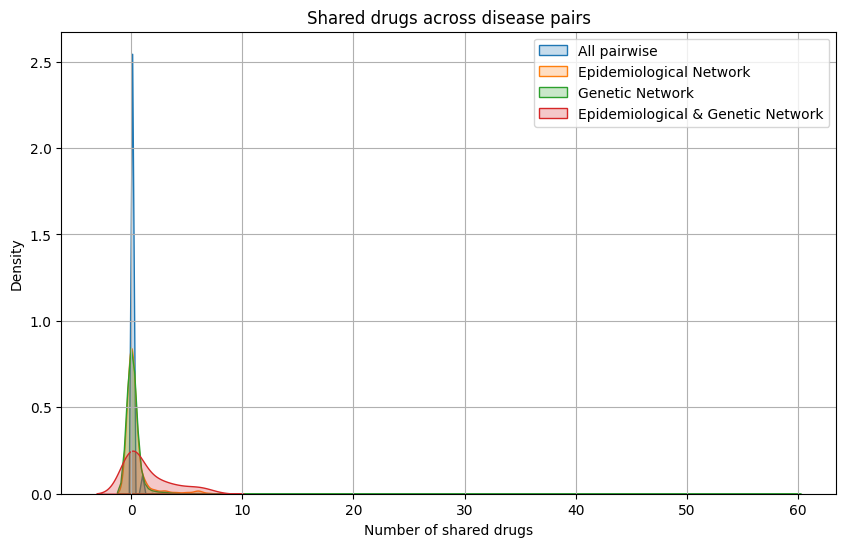

In [25]:

# Create the density plot
plt.figure(figsize=(10, 6))
sns.kdeplot([len(set(disease_approveddrugs_dict[disA]) & set(disease_approveddrugs_dict[disB])) for disA,disB in tot_disease_with_drugs_pairs_list], 
            label="All pairwise", fill=True)
sns.kdeplot([len(set(disease_approveddrugs_dict[disA]) & set(disease_approveddrugs_dict[disB])) for disA,disB in epidemiological_disease_pairs_with_drugs], 
            label="Epidemiological Network", fill=True)
sns.kdeplot([len(set(disease_approveddrugs_dict[disA]) & set(disease_approveddrugs_dict[disB])) for disA,disB in genetic_disease_pairs_with_drugs],
            label="Genetic Network", fill=True)
sns.kdeplot([len(set(disease_approveddrugs_dict[disA]) & set(disease_approveddrugs_dict[disB])) for disA,disB in genetic_and_epidemiological_disease_pairs_with_drugs],
            label="Epidemiological & Genetic Network", fill=True)

# Customize the plot
plt.xlabel("Number of shared drugs")
plt.ylabel("Density")
#plt.xscale("log")
plt.title("Shared drugs across disease pairs")
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

C:\Users\salvo\AppData\Local\Temp\ipykernel_12800\218218697.py:26: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(data=data, scale="width")


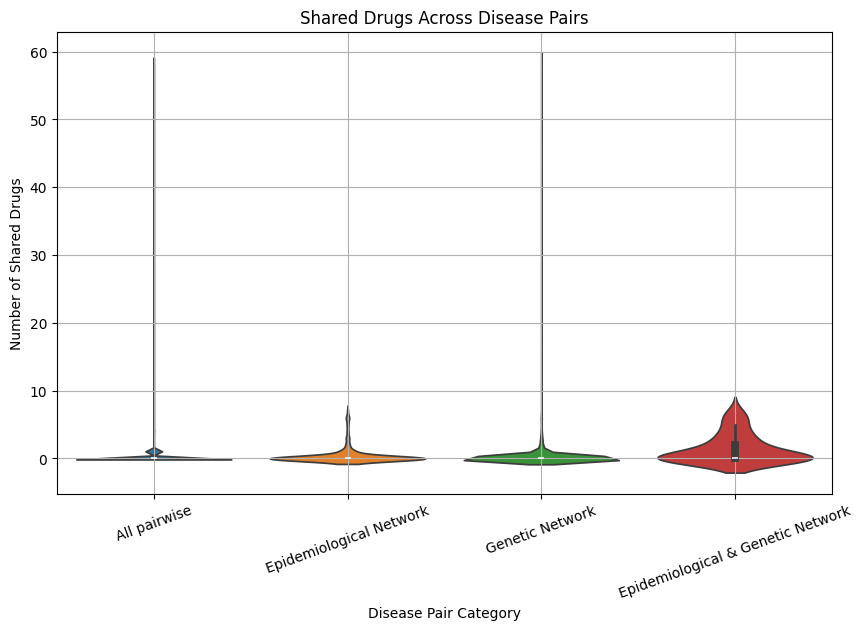

In [26]:

# Compute the number of shared drugs for each category
data = [
    [len(set(disease_approveddrugs_dict[disA]) & set(disease_approveddrugs_dict[disB])) 
     for disA, disB in tot_disease_with_drugs_pairs_list],
    
    [len(set(disease_approveddrugs_dict[disA]) & set(disease_approveddrugs_dict[disB])) 
     for disA, disB in epidemiological_disease_pairs_with_drugs],
    
    [len(set(disease_approveddrugs_dict[disA]) & set(disease_approveddrugs_dict[disB])) 
     for disA, disB in genetic_disease_pairs_with_drugs],
    
    [len(set(disease_approveddrugs_dict[disA]) & set(disease_approveddrugs_dict[disB])) 
     for disA, disB in genetic_and_epidemiological_disease_pairs_with_drugs]
]

# Labels for each violin plot
labels = [
    "All pairwise",
    "Epidemiological Network",
    "Genetic Network",
    "Epidemiological & Genetic Network"
]

# Create the violin plot
plt.figure(figsize=(10, 6))
sns.violinplot(data=data, scale="width")

# Customize the plot
plt.xticks(ticks=range(len(labels)), labels=labels, rotation=20)  # Set x-axis labels
plt.xlabel("Disease Pair Category")
plt.ylabel("Number of Shared Drugs")
#plt.yscale("log")  # Keep logarithmic scale
plt.title("Shared Drugs Across Disease Pairs")
plt.grid(True)

plt.savefig('Figures/Fig5C_shareddrugs_disease_pairs.pdf',format='pdf',dpi=300, bbox_inches = "tight")
# Show the plot
plt.show()

In [30]:
#Let's create a table with the disease pairs and their share drugs
disease_drugs_shared_df = pd.DataFrame()

disA_list = []
disB_list = []
epidemiological_status_list = []
genetic_status_list = []
shared_drug_list = []


for dispair in tot_disease_with_drugs_pairs_list:
    disA = dispair[0]
    disB = dispair[1]
    disA_list.append(disA)
    disB_list.append(disB)
    if (disA,disB) in epidemiological_disease_pairs_with_drugs or (disB,disA) in epidemiological_disease_pairs_with_drugs:
        epidemiological_status_list.append(True)
    else:
        epidemiological_status_list.append(False)
    if (disA,disB) in genetic_disease_pairs_with_drugs or (disB,disA) in genetic_disease_pairs_with_drugs:
        genetic_status_list.append(True)
    else:
        genetic_status_list.append(False)
    shared_drugs_set = set(disease_approveddrugs_dict[disA])&set(disease_approveddrugs_dict[disB])
    shared_drug_list.append(str(shared_drugs_set))

disease_drugs_shared_df["Disease A"] = disA_list
disease_drugs_shared_df["Disease B"] = disB_list
disease_drugs_shared_df["Epidemiological network"] = epidemiological_status_list
disease_drugs_shared_df["Genetic network"] = genetic_status_list
disease_drugs_shared_df["Shared drugs"] = shared_drug_list

disease_drugs_shared_df.head()



,Disease A,Disease B,Epidemiological network,Genetic network,Shared drugs
0,N19,N80,False,False,set()
1,N19,A20,False,False,set()
2,N19,L64,False,True,set()
3,N19,G30,False,False,set()
4,N19,L80,False,False,set()


In [32]:
disease_drugs_shared_df.to_csv("output/Supp_Tab4_disease_drugs_shared_df.csv")

/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_3553/1331459011.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Category", y="Shared Drugs",
/var/folders/0b/z0_jtrl111x5sn006y224x0w0000gq/T/ipykernel_3553/1331459011.py:40: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(data=df, x="Category", y="Shared Drugs",


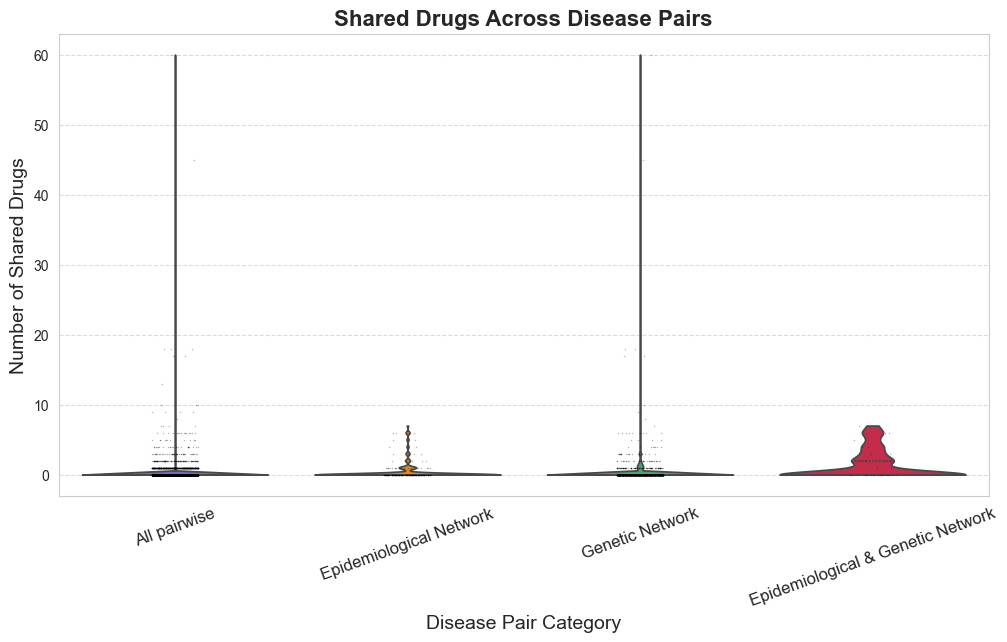

In [103]:

# Define data categories
categories = [
    "All pairwise",
    "Epidemiological Network",
    "Genetic Network",
    "Epidemiological & Genetic Network"
]

# Generate the data (Replace with actual data)
data = [
    [len(set(disease_approveddrugs_dict[disA]) & set(disease_approveddrugs_dict[disB])) 
     for disA, disB in tot_disease_with_drugs_pairs_list],
    
    [len(set(disease_approveddrugs_dict[disA]) & set(disease_approveddrugs_dict[disB])) 
     for disA, disB in epidemiological_disease_pairs_with_drugs],
    
    [len(set(disease_approveddrugs_dict[disA]) & set(disease_approveddrugs_dict[disB])) 
     for disA, disB in genetic_disease_pairs_with_drugs],
    
    [len(set(disease_approveddrugs_dict[disA]) & set(disease_approveddrugs_dict[disB])) 
     for disA, disB in genetic_and_epidemiological_disease_pairs_with_drugs]
]

# Convert data into a DataFrame
df = pd.DataFrame({
    "Category": np.repeat(categories, [len(d) for d in data]), 
    "Shared Drugs": np.concatenate(data)
})

# Set seaborn style
sns.set_style("whitegrid")

# Create figure
plt.figure(figsize=(12, 6))

# Define colors
palette = ["#6A5ACD", "#FF8C00", "#3CB371", "#DC143C"]

# Plot violin with bandwidth adjustment and split to optimize
sns.violinplot(data=df, x="Category", y="Shared Drugs", 
               palette=palette, scale="width", bw_adjust=0.5, 
               inner="quartile", cut=0)

# Overlay fast scatterplot instead of swarmplot
sns.stripplot(data=df, x="Category", y="Shared Drugs", 
              color="black", alpha=0.3, size=1, jitter=True)

# Customize aesthetics
plt.xticks(rotation=20, fontsize=12)
plt.xlabel("Disease Pair Category", fontsize=14)
plt.ylabel("Number of Shared Drugs", fontsize=14)
plt.title("Shared Drugs Across Disease Pairs", fontsize=16, fontweight="bold")
#plt.yscale("log")  # Log scale for better visibility
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Show plot
plt.show()

In [11]:
#Let's import the dictionary with the approved drugs-genes annotations from DrugBank
with open('input/fda_approved_drug_gene_name_drugbank_2023.pickle', 'rb') as handle:
    fda_approved_drgs_dict = pk.load(handle)

#Let's import the diseases
with open('output/allsources_icd_gene_dict_unified.pickle', 'rb') as handle:
    icd_genes_dict = pk.load(handle)

In [12]:
genetic_background = set([x for xs in list(icd_genes_dict.values()) for x in xs]).union(set([x for xs in list(fda_approved_drgs_dict.values()) for x in xs]))
len(genetic_background)

18950

In [35]:
#Let's check that the amount of diseases that have approved/indicated drugs also from a molecular point of view

#First, we need to find the statistically significant disease-drug associations:
drug_intersection_pval_dict = {}
drug_intersection_fdr_dict = {}
drug_intersection_sigfdr_dict = {}

for dis,genelist_A in icd_genes_dict.items():
    for drug,genelist_B in fda_approved_drgs_dict.items():
        drug_intersection_pval = float(fisher_test(set(genelist_A),set(genelist_B),len(genetic_background)))
        drug_intersection_pval_dict[(dis,drug)] = drug_intersection_pval
        
drug_intersection_adj_pval_list = fdr_adjustment(list(drug_intersection_pval_dict.values()),0.05)
pair_list=list(drug_intersection_pval_dict.keys())
for i in range(len(drug_intersection_adj_pval_list)):
    drug_intersection_fdr_dict[pair_list[i]]=drug_intersection_adj_pval_list[i]

for dis_pair,fdr in drug_intersection_fdr_dict.items():
    if fdr<0.05:
        drug_intersection_sigfdr_dict[dis_pair] = fdr

dis_mol_sig_drug_dict = {}
for dis,genelist_A in icd_genes_dict.items():
    drug_list = []
    for dis_pair in drug_intersection_sigfdr_dict.keys():
        if dis==dis_pair[0]:
            drug_list.append(dis_pair[1])
    if len(drug_list)>0:
        dis_mol_sig_drug_dict[dis] = drug_list
        
print(len(dis_mol_sig_drug_dict))

757


In [39]:
disease_drug_mol_df = pd.DataFrame()

dis_list = []
drug_list = []
fdr_list = []
indication_list = []


for dis_drug,fdr in drug_intersection_sigfdr_dict.items():
    dis = dis_drug[0]
    drug = dis_drug[1]
    dis_list.append(dis)
    drug_list.append(drug)
    fdr_list.append(str(fdr))
    try:
        if drug in disease_approveddrugs_dict[dis]:
            indication_list.append(True)
        else:
            indication_list.append(False)
    except:
        indication_list.append(False)


disease_drug_mol_df["Disease"] = dis_list
disease_drug_mol_df["Drug"] = drug_list
disease_drug_mol_df["FDR (molecular overlap)"] = fdr_list
disease_drug_mol_df["Reported indication"] = indication_list

disease_drug_mol_df.head()

,Disease,Drug,FDR (molecular overlap),Reported indication
0,B59,Pomalidomide,0.0014543341174410801,False
1,B59,Foreskin fibroblast (neonatal),0.008136347179040073,False
2,B59,Peginterferon alfa-2b,0.038528916336211236,False
3,B59,Interferon beta-1b,0.0147884840585972,False
4,B59,Interferon alfa-2b,0.0147884840585972,False


In [40]:
disease_drug_mol_df.to_csv("output/Supp_Tab5_disease_molecular_drugs_df.csv")

In [40]:
#Let's check that the amount of diseases that have approved/indicated drugs also from a molecular point of view

disease_approveddrugs_shared_mol_pval_dict = {}
disease_approveddrugs_shared_mol_fdr_dict = {}
disease_approveddrugs_shared_mol_sigfdr_dict = {}

for disA,druglist in disease_approveddrugs_dict.items():
    try:
        drug_overlap_pval = float(fisher_test(set(druglist),set(dis_mol_sig_drug_dict[disA]),len(tot_drug_list)))
        disease_approveddrugs_shared_mol_pval_dict[disA]=drug_overlap_pval
    except:
        pass
    
drug_intersection_adj_pval_list = fdr_adjustment(list(disease_approveddrugs_shared_mol_pval_dict.values()),0.05)
pair_list=list(disease_approveddrugs_shared_mol_pval_dict.keys())
for i in range(len(drug_intersection_adj_pval_list)):
    disease_approveddrugs_shared_mol_fdr_dict[pair_list[i]]=drug_intersection_adj_pval_list[i]

for dis_pair,fdr in disease_approveddrugs_shared_mol_fdr_dict.items():
    if fdr<0.05:
        disease_approveddrugs_shared_mol_sigfdr_dict[dis_pair] = fdr


print(len(disease_approveddrugs_shared_mol_sigfdr_dict))

6


In [41]:
#Let's check that the amount of diseases that have approved/indicated drugs also from a molecular point of view

disease_approveddrugs_shared_mol_oneshared_dict = []

for disA,druglist in disease_approveddrugs_dict.items():
    try:
        drug_overlap = len(set(druglist)&set(dis_mol_sig_drug_dict[disA]))
        if drug_overlap>0:
            disease_approveddrugs_shared_mol_oneshared_dict.append(disA)
    except:
        pass

print(len(disease_approveddrugs_shared_mol_oneshared_dict))

65


In [37]:
len(disease_approveddrugs_dict)

260

In [52]:
disease_approveddrugs_dict["N80"]

['Leuprolide',
 'Goserelin',
 'Medroxyprogesterone acetate',
 'Nafarelin',
 'Norethisterone',
 'Danazol',
 'Buserelin',
 'Dienogest',
 'Gestrinone']

In [53]:
len(dis_mol_sig_drug_dict["N80"])

55

In [ ]:
#Let's do the same for the trajectories

In [13]:
with open('output/male_trajectories_dict_filtered_unique_agglomerated_genes.pickle', 'rb') as handle:
    male_trajectories_dict_filtered_unique_agglomerated_genes = pk.load(handle)
with open('output/female_trajectories_dict_filtered_unique_agglomerated_genes.pickle', 'rb') as handle:
    female_trajectories_dict_filtered_unique_agglomerated_genes = pk.load(handle)


In [14]:
#Let's check that the amount of diseases that have approved/indicated drugs also from a molecular point of view

#First, we need to find the statistically significant disease-drug associations:
male_trajectories_dict_filtered_unique_drug_intersection_pval_dict = {}
male_trajectories_dict_filtered_unique_drug_intersection_fdr_dict = {}
male_trajectories_dict_filtered_unique_drug_intersection_sigfdr_dict = {}

for dis,genelist_A in male_trajectories_dict_filtered_unique_agglomerated_genes.items():
    for drug,genelist_B in fda_approved_drgs_dict.items():
        drug_intersection_pval = float(fisher_test(set(genelist_A),set(genelist_B),len(genetic_background)))
        male_trajectories_dict_filtered_unique_drug_intersection_pval_dict[(dis,drug)] = drug_intersection_pval
        
drug_intersection_adj_pval_list = fdr_adjustment(list(male_trajectories_dict_filtered_unique_drug_intersection_pval_dict.values()),0.05)
pair_list=list(male_trajectories_dict_filtered_unique_drug_intersection_pval_dict.keys())
for i in range(len(drug_intersection_adj_pval_list)):
    male_trajectories_dict_filtered_unique_drug_intersection_fdr_dict[pair_list[i]]=drug_intersection_adj_pval_list[i]

for dis_pair,fdr in male_trajectories_dict_filtered_unique_drug_intersection_fdr_dict.items():
    if fdr<0.05:
        male_trajectories_dict_filtered_unique_drug_intersection_sigfdr_dict[dis_pair] = fdr

male_trajectories_dict_filtered_unique_mol_sig_drug_dict = {}
for dis,genelist_A in male_trajectories_dict_filtered_unique_agglomerated_genes.items():
    drug_list = []
    for dis_pair in male_trajectories_dict_filtered_unique_drug_intersection_sigfdr_dict.keys():
        if dis==dis_pair[0]:
            drug_list.append(dis_pair[1])
    if len(drug_list)>0:
        male_trajectories_dict_filtered_unique_mol_sig_drug_dict[dis] = drug_list
        
print(len(male_trajectories_dict_filtered_unique_mol_sig_drug_dict))

311


In [15]:
male_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df = pd.DataFrame()

trj_list = []
dis_list = []
drug_list = []
fdr_list = []


for trj_drug,fdr in male_trajectories_dict_filtered_unique_drug_intersection_sigfdr_dict.items():
    trj = trj_drug[0]
    drug = trj_drug[1]
    dislist = male_trajectories_dict_filtered_unique[trj]
    trj_list.append(trj)
    dis_list.append(str(dislist))
    drug_list.append(drug)
    fdr_list.append(str(fdr))


male_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df["Trajectory"]=trj_list
male_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df["Disease list"]=dis_list
male_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df["Drug"]=drug_list
male_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df["FDR"]=fdr_list

male_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df.to_csv("output/male_trj_mol_drug.csv")



In [16]:
#Let's check that the amount of diseases that have approved/indicated drugs also from a molecular point of view

#First, we need to find the statistically significant disease-drug associations:
female_trajectories_dict_filtered_unique_drug_intersection_pval_dict = {}
female_trajectories_dict_filtered_unique_drug_intersection_fdr_dict = {}
female_trajectories_dict_filtered_unique_drug_intersection_sigfdr_dict = {}

for dis,genelist_A in female_trajectories_dict_filtered_unique_agglomerated_genes.items():
    for drug,genelist_B in fda_approved_drgs_dict.items():
        drug_intersection_pval = float(fisher_test(set(genelist_A),set(genelist_B),len(genetic_background)))
        female_trajectories_dict_filtered_unique_drug_intersection_pval_dict[(dis,drug)] = drug_intersection_pval
        
drug_intersection_adj_pval_list = fdr_adjustment(list(female_trajectories_dict_filtered_unique_drug_intersection_pval_dict.values()),0.05)
pair_list=list(female_trajectories_dict_filtered_unique_drug_intersection_pval_dict.keys())
for i in range(len(drug_intersection_adj_pval_list)):
    female_trajectories_dict_filtered_unique_drug_intersection_fdr_dict[pair_list[i]]=drug_intersection_adj_pval_list[i]

for dis_pair,fdr in female_trajectories_dict_filtered_unique_drug_intersection_fdr_dict.items():
    if fdr<0.05:
        female_trajectories_dict_filtered_unique_drug_intersection_sigfdr_dict[dis_pair] = fdr

female_trajectories_dict_filtered_unique_mol_sig_drug_dict = {}
for dis,genelist_A in female_trajectories_dict_filtered_unique_agglomerated_genes.items():
    drug_list = []
    for dis_pair in female_trajectories_dict_filtered_unique_drug_intersection_sigfdr_dict.keys():
        if dis==dis_pair[0]:
            drug_list.append(dis_pair[1])
    if len(drug_list)>0:
        female_trajectories_dict_filtered_unique_mol_sig_drug_dict[dis] = drug_list
        
print(len(female_trajectories_dict_filtered_unique_mol_sig_drug_dict))

294


In [18]:
female_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df = pd.DataFrame()

trj_list = []
dis_list = []
drug_list = []
fdr_list = []


for trj_drug,fdr in female_trajectories_dict_filtered_unique_drug_intersection_sigfdr_dict.items():
    trj = trj_drug[0]
    drug = trj_drug[1]
    dislist = female_trajectories_dict_filtered_unique[trj]
    trj_list.append(trj)
    dis_list.append(str(dislist))
    drug_list.append(drug)
    fdr_list.append(str(fdr))


female_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df["Trajectory"]=trj_list
female_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df["Disease list"]=dis_list
female_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df["Drug"]=drug_list
female_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df["FDR"]=fdr_list

female_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df.to_csv("output/female_trj_mol_drug.csv")



In [77]:
female_trajectories_dict_filtered_unique_mol_sig_drug_dict

{'1': ['Vandetanib',
  'Nicotine',
  'Methadone',
  'Meperidine',
  'Quinine',
  'Clonidine',
  'Verapamil',
  'Ofloxacin',
  'Pazopanib',
  'Loperamide',
  'Procainamide',
  'Tiotropium',
  'Ruxolitinib',
  'Tocofersolan',
  'Guanidine',
  'Solriamfetol'],
 '2': ['Human C1-esterase inhibitor',
  'Kappadione',
  'Turoctocog alfa pegol',
  'Vandetanib',
  'Afatinib',
  'Foreskin keratinocyte (neonatal)',
  'Aldesleukin',
  'Pseudoephedrine',
  'Foreskin fibroblast (neonatal)',
  'Cisplatin',
  'Carboplatin',
  'Linzagolix',
  'Caffeine',
  'Nevirapine',
  'Acetaminophen',
  'Amitriptyline',
  'Methadone',
  'Clozapine',
  'Zolpidem',
  'Meperidine',
  'Imipramine',
  'Duloxetine',
  'Haloperidol',
  'Imatinib',
  'Estrone',
  'Verapamil',
  'Tamoxifen',
  'Etoposide',
  'Ethanol',
  'Azathioprine',
  'Rifampicin',
  'Pimozide',
  'Nifedipine',
  'Ofloxacin',
  'Orphenadrine',
  'Flunarizine',
  'Asenapine',
  'Pazopanib',
  'Vemurafenib',
  'Human thrombin',
  'Nelfinavir',
  'Indinavir

In [84]:
male_trajectories_dict_filtered_unique_with_drugs_dict_explicit = {}

for trj,disset in male_trajectories_dict_filtered_unique_with_drugs_dict.items():
    drug_list = []
    for dis in disset:
        drug_list.extend(disease_approveddrugs_dict[dis])
    male_trajectories_dict_filtered_unique_with_drugs_dict_explicit[trj] = set(drug_list)


female_trajectories_dict_filtered_unique_with_drugs_dict_explicit = {}

for trj,disset in female_trajectories_dict_filtered_unique_with_drugs_dict.items():
    drug_list = []
    for dis in disset:
        drug_list.extend(disease_approveddrugs_dict[dis])
    female_trajectories_dict_filtered_unique_with_drugs_dict_explicit[trj] = set(drug_list)


In [88]:
#Let's check that the amount of diseases that have approved/indicated drugs also from a molecular point of view

male_approveddrugs_shared_mol_pval_dict = {}
male_approveddrugs_shared_mol_fdr_dict = {}
male_approveddrugs_shared_mol_sigfdr_dict = {}

for disA,druglist in male_trajectories_dict_filtered_unique_with_drugs_dict_explicit.items():
    try:
        drug_overlap_pval = float(fisher_test(set(druglist),set(male_trajectories_dict_filtered_unique_mol_sig_drug_dict[disA]),len(tot_drug_list)))
        male_approveddrugs_shared_mol_pval_dict[disA]=drug_overlap_pval
    except:
        pass
    
drug_intersection_adj_pval_list = fdr_adjustment(list(male_approveddrugs_shared_mol_pval_dict.values()),0.05)
pair_list=list(male_approveddrugs_shared_mol_pval_dict.keys())
for i in range(len(drug_intersection_adj_pval_list)):
    male_approveddrugs_shared_mol_fdr_dict[pair_list[i]]=drug_intersection_adj_pval_list[i]

for dis_pair,fdr in male_approveddrugs_shared_mol_fdr_dict.items():
    if fdr<0.05:
        male_approveddrugs_shared_mol_sigfdr_dict[dis_pair] = fdr


print(len(male_approveddrugs_shared_mol_sigfdr_dict))

0


In [90]:
#Let's check that the amount of diseases that have approved/indicated drugs also from a molecular point of view

female_approveddrugs_shared_mol_pval_dict = {}
female_approveddrugs_shared_mol_fdr_dict = {}
female_approveddrugs_shared_mol_sigfdr_dict = {}

for disA,druglist in female_trajectories_dict_filtered_unique_with_drugs_dict_explicit.items():
    try:
        drug_overlap_pval = float(fisher_test(set(druglist),set(female_trajectories_dict_filtered_unique_mol_sig_drug_dict[disA]),len(tot_drug_list)))
        female_approveddrugs_shared_mol_pval_dict[disA]=drug_overlap_pval
    except:
        pass
    
drug_intersection_adj_pval_list = fdr_adjustment(list(female_approveddrugs_shared_mol_pval_dict.values()),0.05)
pair_list=list(female_approveddrugs_shared_mol_pval_dict.keys())
for i in range(len(drug_intersection_adj_pval_list)):
    female_approveddrugs_shared_mol_fdr_dict[pair_list[i]]=drug_intersection_adj_pval_list[i]

for dis_pair,fdr in female_approveddrugs_shared_mol_fdr_dict.items():
    if fdr<0.05:
        female_approveddrugs_shared_mol_sigfdr_dict[dis_pair] = fdr


print(len(female_approveddrugs_shared_mol_sigfdr_dict))

4


In [91]:
female_approveddrugs_shared_mol_sigfdr_dict

{'71': np.float64(0.003408591591977155),
 '73': np.float64(0.003408591591977155),
 '428': np.float64(0.02786120295864357),
 '441': np.float64(0.003408591591977155)}

In [92]:
female_trajectories_dict_filtered_unique_with_drugs_dict["71"]

{'D50', 'E03', 'E06'}

In [95]:
female_trajectories_dict_filtered_unique_with_drugs_dict["441"]

{'M19', 'M77'}

In [98]:
female_trajectories_dict_filtered_unique_with_drugs_dict_explicit["71"] & set(female_trajectories_dict_filtered_unique_mol_sig_drug_dict["71"])

{'Levothyroxine',
 'Liotrix',
 'Sodium ferric gluconate complex',
 'Thyroid, porcine'}